# Notebook 06 — CRSP EDA and Mathematical Tests

## Purpose

This notebook repeats the exploratory analysis using the corrected CRSP data.

For every mathematical test, we answer:

1. **What question does it answer?**
2. **Why is that question relevant?**
3. **What is the null hypothesis?**
4. **How do we interpret the result?**
5. **What decision does it support?**

## Tests covered

- Augmented Dickey–Fuller test
- Jarque–Bera test
- Ljung–Box test
- ARCH-LM test
- ACF of raw and squared returns

Run this notebook before fitting the final GARCH model.

In [1]:
from pathlib import Path
import sys
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

# Find the project root whether the notebook is launched from:
#   project/
# or:
#   project/notebooks/
CURRENT = Path.cwd().resolve()

if (CURRENT / "data").exists():
    PROJECT_ROOT = CURRENT
elif CURRENT.name == "notebooks" and (CURRENT.parent / "data").exists():
    PROJECT_ROOT = CURRENT.parent
else:
    possible_roots = [CURRENT, *CURRENT.parents]
    matches = [p for p in possible_roots if (p / "data").exists() and (p / "notebooks").exists()]
    if not matches:
        raise FileNotFoundError(
            "Could not find the project root. Open the sp500-forecasting-dissertation "
            "folder in VS Code, then run this notebook again."
        )
    PROJECT_ROOT = matches[0]

DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
REPORT_TABLES = PROJECT_ROOT / "reports" / "tables"
REPORT_FIGURES = PROJECT_ROOT / "reports" / "figures"
MODEL_DIR = PROJECT_ROOT / "reports" / "models"

for folder in [DATA_PROCESSED, REPORT_TABLES, REPORT_FIGURES, MODEL_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Python:", sys.executable)
print("Python version:", sys.version.split()[0])

Project root: <project_root>
Python: /opt/anaconda3/envs/dissertation/bin/python
Python version: 3.11.15


In [2]:
def find_crsp_panel(processed_folder: Path) -> Path:
    """Find the best available corrected CRSP parquet file."""
    preferred_names = [
        "crsp_sp500_daily_corrected_2010_2024.parquet",
        "crsp_sp500_daily_corrected.parquet",
        "crsp_daily_corrected_2010_2024.parquet",
        "crsp_daily_2010_2024.parquet",
    ]

    for name in preferred_names:
        path = processed_folder / name
        if path.exists():
            return path

    candidates = sorted(
        processed_folder.glob("*.parquet"),
        key=lambda p: p.stat().st_mtime,
        reverse=True,
    )

    if not candidates:
        raise FileNotFoundError(
            f"No parquet file was found in {processed_folder}. "
            "Run and save the corrected CRSP data notebook first."
        )

    print("No preferred filename found. Using the newest parquet file:")
    return candidates[0]


PANEL_PATH = find_crsp_panel(DATA_PROCESSED)
panel = pd.read_parquet(PANEL_PATH).copy()
panel.columns = [str(c).strip().lower() for c in panel.columns]

# Accept the possible names used in the earlier audit notebook.
return_candidates = ["ret", "combined_return", "ret_combined"]
return_source = next((c for c in return_candidates if c in panel.columns), None)

required_base = {"permno", "date"}
missing_base = required_base.difference(panel.columns)

if missing_base:
    raise ValueError(f"Missing required columns: {sorted(missing_base)}")

if return_source is None:
    raise ValueError(
        "Could not find a return column. Expected one of: "
        f"{return_candidates}. Found: {panel.columns.tolist()}"
    )

panel["date"] = pd.to_datetime(panel["date"])
panel["permno"] = pd.to_numeric(panel["permno"], errors="coerce").astype("Int64")
panel[return_source] = pd.to_numeric(panel[return_source], errors="coerce")

if "mktcap" in panel.columns:
    panel["mktcap"] = pd.to_numeric(panel["mktcap"], errors="coerce")

panel = (
    panel.dropna(subset=["permno", "date"])
         .sort_values(["date", "permno"])
         .reset_index(drop=True)
)

# IMPORTANT DECISION:
# "simple" keeps CRSP total returns, including a possible -100% delisting return.
# "log" uses log(1 + return), but an exact -100% return cannot be logged.
RETURN_MODE = "simple"

if RETURN_MODE == "simple":
    panel["model_return"] = panel[return_source]
elif RETURN_MODE == "log":
    impossible_for_log = panel[return_source] <= -1
    print("Rows not usable as log-returns:", int(impossible_for_log.sum()))
    panel["model_return"] = np.where(
        panel[return_source] > -1,
        np.log1p(panel[return_source]),
        np.nan,
    )
else:
    raise ValueError("RETURN_MODE must be 'simple' or 'log'.")

print("Loaded:", PANEL_PATH)
print("Rows:", len(panel))
print("Dates:", panel["date"].min(), "to", panel["date"].max())
print("Unique PERMNOs:", panel["permno"].nunique())
print("Return source:", return_source)
print("Return mode:", RETURN_MODE)
print("Missing modelling returns:", panel["model_return"].isna().sum())

Loaded: <project_root>/data/processed/crsp_sp500_daily_corrected_2010_2024.parquet
Rows: 1711517
Dates: 2010-01-04 00:00:00 to 2024-12-31 00:00:00
Unique PERMNOs: 740
Return source: ret
Return mode: simple
Missing modelling returns: 60


## Return choice

The notebook defaults to **simple CRSP total returns**.

Why?

- An exact −100% delisting return is valid as a simple return.
- Its log-return would be `log(0)`, which is negative infinity.
- We must not silently delete or alter that observation.

After discussing the final target with the supervisor, change `RETURN_MODE` in the loading cell if needed.

In [3]:
# Basic integrity checks

audit = {
    "rows": len(panel),
    "unique_permnos": panel["permno"].nunique(),
    "start_date": panel["date"].min(),
    "end_date": panel["date"].max(),
    "duplicate_permno_dates": panel.duplicated(["permno", "date"]).sum(),
    "missing_model_returns": panel["model_return"].isna().sum(),
    "returns_below_minus_100_percent": (panel["model_return"] < -1).sum(),
}

pd.Series(audit, name="result")

rows                                           1711517
unique_permnos                                     740
start_date                         2010-01-04 00:00:00
end_date                           2024-12-31 00:00:00
duplicate_permno_dates                               0
missing_model_returns                               60
returns_below_minus_100_percent                      0
Name: result, dtype: object

## Choose a small, understandable sample

The final modelling panel may contain hundreds of securities. For the first formal EDA table, we select the ten securities with the most valid observations.

This is only for understanding and presentation. Later experiments use the chosen top-100, top-200 and top-300 universes.

In [4]:
counts = (
    panel.dropna(subset=["model_return"])
         .groupby("permno")
         .size()
         .sort_values(ascending=False)
)

sample_permnos = counts.head(10).index.astype(int).tolist()
sample = panel[panel["permno"].isin(sample_permnos)].copy()

print("Sample PERMNOs:", sample_permnos)

label_map = {}
for permno in sample_permnos:
    stock_rows = sample[sample["permno"] == permno]
    if "ticker" in stock_rows.columns and stock_rows["ticker"].notna().any():
        label = str(stock_rows["ticker"].dropna().iloc[-1])
    else:
        label = str(permno)
    label_map[permno] = label

label_map

Sample PERMNOs: [60871, 45751, 48725, 48653, 48506, 47896, 89179, 46886, 46674, 46578]


{60871: 'ADI',
 45751: 'MMC',
 48725: 'UNP',
 48653: 'HUM',
 48506: 'MCO',
 47896: 'JPM',
 89179: 'ELV',
 46886: 'KLAC',
 46674: 'GPC',
 46578: 'CLX'}

## 1. Augmented Dickey–Fuller test

**Question:** Is the return series stationary?

**Why:** ARMA and GARCH are designed for a series whose basic behaviour is reasonably stable.

**Null hypothesis:** The series has a unit root and is non-stationary.

**Interpretation:**

- p-value below 0.05: reject the unit-root null.
- p-value at or above 0.05: not enough evidence to call the series stationary.

**Decision supported:** Whether modelling returns as a stationary time series is reasonable.

## 2. Jarque–Bera test

**Question:** Are returns normally distributed?

**Why:** Financial returns often have skewness and heavy tails. This influences whether a normal or Student-t error distribution is more sensible for GARCH.

**Null hypothesis:** The data is normally distributed.

**Interpretation:**

- p-value below 0.05: reject normality.
- p-value at or above 0.05: not enough evidence to reject normality.

**Decision supported:** Whether normal model errors are likely to be too restrictive.

## 3. Ljung–Box test

**Question:** Are several autocorrelations jointly equal to zero?

**Why:** An ACF plot is visual. Ljung–Box gives a formal test.

**Null hypothesis:** There is no serial correlation up to the chosen lag.

**Decision supported:**

- Applied to raw returns: whether linear time dependence exists.
- Applied to squared returns: whether volatility clustering exists.
- Applied after modelling: whether dependence remains in residuals.

## 4. ARCH-LM test

**Question:** Is volatility changing through time in a predictable way?

**Why:** GARCH is only justified if there are ARCH effects or volatility clustering.

**Null hypothesis:** There are no ARCH effects.

**Interpretation:**

- p-value below 0.05: evidence of time-varying volatility.
- p-value at or above 0.05: little evidence of ARCH effects.

**Decision supported:** Whether a GARCH-type volatility model is appropriate.

In [5]:
from scipy import stats
from statsmodels.tsa.stattools import adfuller
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch


def safe_adf(series: pd.Series):
    clean = series.dropna()
    if len(clean) < 50:
        return np.nan, np.nan
    result = adfuller(clean, autolag="AIC")
    return float(result[0]), float(result[1])


def safe_jarque_bera(series: pd.Series):
    clean = series.dropna()
    if len(clean) < 20:
        return np.nan, np.nan
    result = stats.jarque_bera(clean)
    return float(result.statistic), float(result.pvalue)


def safe_ljung_box(series: pd.Series, lag: int = 10):
    clean = series.dropna()
    if len(clean) <= lag + 5:
        return np.nan
    result = acorr_ljungbox(clean, lags=[lag], return_df=True)
    return float(result["lb_pvalue"].iloc[0])


def safe_arch_lm(series: pd.Series, lags: int = 10):
    clean = series.dropna()
    if len(clean) <= lags + 5:
        return np.nan
    lm_stat, lm_pvalue, f_stat, f_pvalue = het_arch(clean, nlags=lags)
    return float(lm_pvalue)

In [6]:
summary_rows = []

for permno in sample_permnos:
    r = (
        sample.loc[sample["permno"] == permno, ["date", "model_return"]]
              .dropna()
              .sort_values("date")
              .set_index("date")["model_return"]
    )

    adf_stat, adf_p = safe_adf(r)
    jb_stat, jb_p = safe_jarque_bera(r)

    summary_rows.append({
        "permno": permno,
        "label": label_map[permno],
        "observations": len(r),
        "mean_percent": r.mean() * 100,
        "std_percent": r.std() * 100,
        "lag1_autocorrelation": r.autocorr(lag=1),
        "squared_lag1_autocorrelation": (r ** 2).autocorr(lag=1),
        "raw_kurtosis": r.kurtosis() + 3,
        "adf_pvalue": adf_p,
        "jarque_bera_pvalue": jb_p,
        "ljung_box_returns_pvalue_lag10": safe_ljung_box(r, lag=10),
        "ljung_box_squared_pvalue_lag10": safe_ljung_box(r ** 2, lag=10),
        "arch_lm_pvalue_lag10": safe_arch_lm(r, lags=10),
    })

eda_table = pd.DataFrame(summary_rows)
eda_table

,permno,label,observations,mean_percent,std_percent,lag1_autocorrelation,squared_lag1_autocorrelation,raw_kurtosis,adf_pvalue,jarque_bera_pvalue,ljung_box_returns_pvalue_lag10,ljung_box_squared_pvalue_lag10,arch_lm_pvalue_lag10
0,60871,ADI,3774,0.076768,1.840382,-0.134618,0.452345,9.381124,6.287273e-27,0.0,2.154629e-20,0.000000e+00,1.165195e-197
1,45751,MMC,3774,0.076025,1.244062,-0.102813,0.231855,14.597634,2.288369e-26,0.0,6.000352e-20,0.000000e+00,5.636592e-167
2,48725,UNP,3774,0.072793,1.565528,-0.067951,0.208866,10.069075,0.000000e+00,0.0,1.128206e-14,0.000000e+00,1.778131e-127
3,48653,HUM,3774,0.068009,1.915172,-0.005278,0.144308,17.824169,3.489194e-27,0.0,5.563478e-04,1.494853e-102,3.892580e-52
4,48506,MCO,3774,0.097093,1.798450,-0.069528,0.299579,12.710705,0.000000e+00,0.0,1.674478e-14,0.000000e+00,5.887023e-172
5,47896,JPM,3774,0.071860,1.749329,-0.097588,0.380023,12.920906,1.472494e-23,0.0,1.426095e-17,0.000000e+00,9.567678e-176
6,89179,ELV,3774,0.069952,1.766195,-0.058707,0.219884,12.655582,3.035724e-25,0.0,3.622962e-15,0.000000e+00,3.548508e-163
7,46886,KLAC,3774,0.116250,2.265623,-0.094527,0.210983,9.435158,0.000000e+00,0.0,4.879133e-20,2.530193e-265,1.146924e-101
8,46674,GPC,3774,0.053864,1.570874,-0.014698,0.173270,28.884518,1.468730e-29,0.0,1.249390e-13,5.732674e-225,2.780677e-111
9,46578,CLX,3774,0.046319,1.322326,-0.052761,0.122903,16.846591,0.000000e+00,0.0,8.759990e-05,1.909937e-32,1.239792e-22


In [7]:
# Add plain-English decisions to make the output easy to explain.

eda_table["stationary_at_5pct"] = eda_table["adf_pvalue"] < 0.05
eda_table["reject_normality_at_5pct"] = eda_table["jarque_bera_pvalue"] < 0.05
eda_table["raw_serial_correlation_at_5pct"] = (
    eda_table["ljung_box_returns_pvalue_lag10"] < 0.05
)
eda_table["volatility_clustering_at_5pct"] = (
    eda_table["arch_lm_pvalue_lag10"] < 0.05
)

display_columns = [
    "label",
    "observations",
    "mean_percent",
    "std_percent",
    "raw_kurtosis",
    "adf_pvalue",
    "jarque_bera_pvalue",
    "ljung_box_returns_pvalue_lag10",
    "arch_lm_pvalue_lag10",
    "stationary_at_5pct",
    "reject_normality_at_5pct",
    "volatility_clustering_at_5pct",
]

eda_table[display_columns].round(4)

,label,observations,mean_percent,std_percent,raw_kurtosis,adf_pvalue,jarque_bera_pvalue,ljung_box_returns_pvalue_lag10,arch_lm_pvalue_lag10,stationary_at_5pct,reject_normality_at_5pct,volatility_clustering_at_5pct
0,ADI,3774,0.0768,1.8404,9.3811,0.0,0.0,0.0000,0.0,True,True,True
1,MMC,3774,0.0760,1.2441,14.5976,0.0,0.0,0.0000,0.0,True,True,True
2,UNP,3774,0.0728,1.5655,10.0691,0.0,0.0,0.0000,0.0,True,True,True
3,HUM,3774,0.0680,1.9152,17.8242,0.0,0.0,0.0006,0.0,True,True,True
4,MCO,3774,0.0971,1.7984,12.7107,0.0,0.0,0.0000,0.0,True,True,True
5,JPM,3774,0.0719,1.7493,12.9209,0.0,0.0,0.0000,0.0,True,True,True
6,ELV,3774,0.0700,1.7662,12.6556,0.0,0.0,0.0000,0.0,True,True,True
7,KLAC,3774,0.1162,2.2656,9.4352,0.0,0.0,0.0000,0.0,True,True,True
8,GPC,3774,0.0539,1.5709,28.8845,0.0,0.0,0.0000,0.0,True,True,True
9,CLX,3774,0.0463,1.3223,16.8466,0.0,0.0,0.0001,0.0,True,True,True


## Visual check for one example stock

The tests provide numbers. The plots help us see the same ideas:

- Raw returns should move around zero.
- Raw-return ACF should usually be weak.
- Squared-return ACF should usually be stronger.

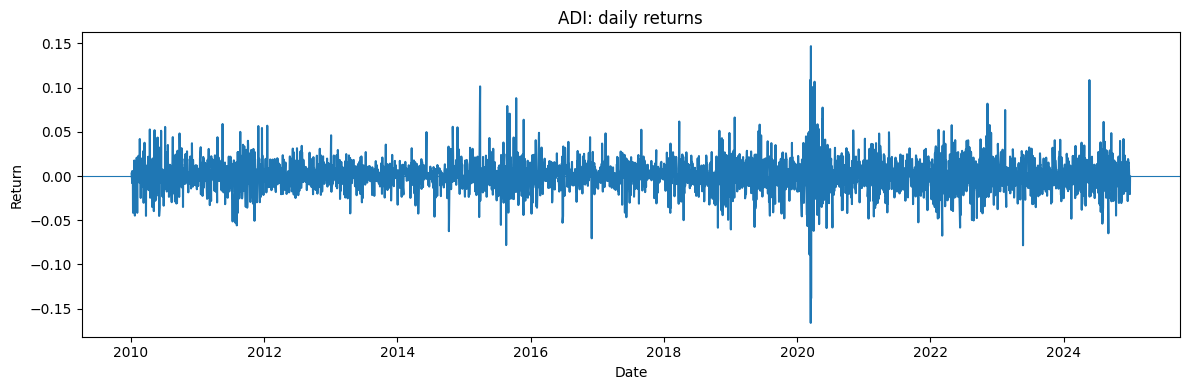

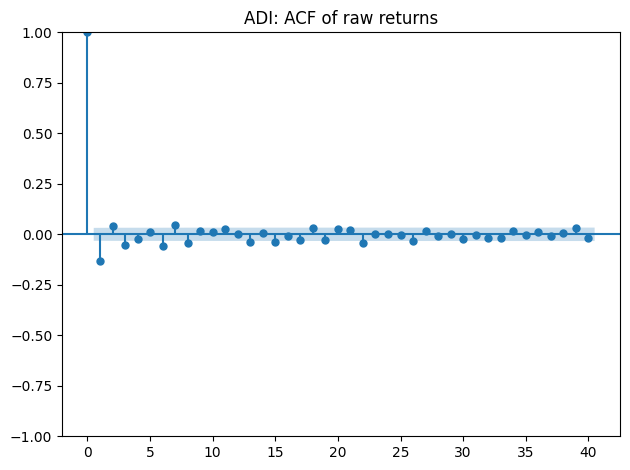

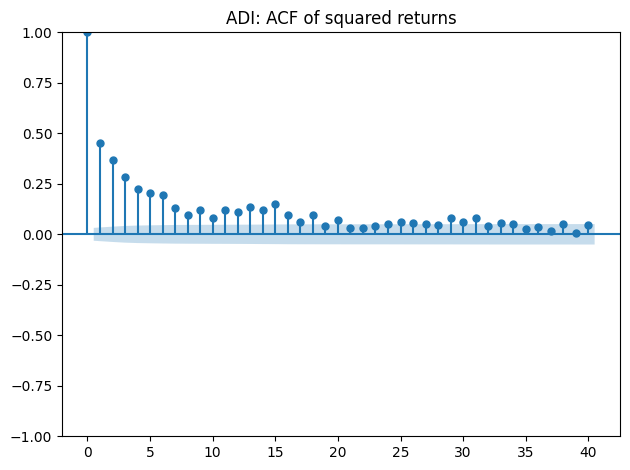

In [8]:
from statsmodels.graphics.tsaplots import plot_acf

example_permno = sample_permnos[0]
example_label = label_map[example_permno]

example_returns = (
    sample.loc[sample["permno"] == example_permno, ["date", "model_return"]]
          .dropna()
          .sort_values("date")
          .set_index("date")["model_return"]
)

plt.figure(figsize=(12, 4))
plt.plot(example_returns.index, example_returns.values)
plt.axhline(0, linewidth=0.8)
plt.title(f"{example_label}: daily returns")
plt.xlabel("Date")
plt.ylabel("Return")
plt.tight_layout()
plt.show()

plot_acf(example_returns, lags=40)
plt.title(f"{example_label}: ACF of raw returns")
plt.tight_layout()
plt.show()

plot_acf(example_returns ** 2, lags=40)
plt.title(f"{example_label}: ACF of squared returns")
plt.tight_layout()
plt.show()

In [9]:
output_path = REPORT_TABLES / "crsp_eda_and_tests.csv"
eda_table.to_csv(output_path, index=False)

print("Saved:", output_path)

Saved: <project_root>/reports/tables/crsp_eda_and_tests.csv


## What to say in the meeting

> I used the ADF test to check stationarity, Jarque–Bera to test normality, Ljung–Box to formally test serial correlation, and ARCH-LM to test volatility clustering. The purpose is not to collect random p-values. Each test supports a modelling decision: returns rather than prices, Student-t errors rather than blindly assuming normality, ARMA only where linear dependence exists, and GARCH where volatility dependence exists.